# SmartStocks — Notebook 1: Data Ingestion & Cleaning

**Goal:** Fetch a 150-stock universe across 10 sectors, understand what the raw data looks like, handle missing values and corporate actions, and sanity-check a few price series visually.

**By the end of this notebook you should be able to answer:**
- What does a raw yfinance OHLCV DataFrame look like?
- Which stocks have missing data, and why?
- What is adjusted close and why does it matter?
- Is the cleaned data plausible? (The plot check)
- How do we persist this so we don't re-fetch every time?

---
## 0. Imports & config

In [132]:
# TODO: import yfinance, pandas, numpy, matplotlib
from pathlib import Path
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO: set matplotlib style
plt.style.use("seaborn-v0_8")

# TODO: define a DATA_DIR path for parquet output (resolve from common kernel cwd layouts)
_cwd = Path.cwd()
if _cwd.name == "backend":
    DATA_DIR = _cwd / "data"
elif (_cwd / "backend").is_dir():
    DATA_DIR = _cwd / "backend" / "data"
elif _cwd.name == "notebooks":
    DATA_DIR = _cwd.parent / "data"
else:
    DATA_DIR = _cwd / "backend" / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# TODO: set a LOOKBACK constant (e.g. '2y')
# how far back to pull stock history
LOOKBACK = "2y"



---
## 1. Define the stock universe

**Your job:** Build a dict mapping each sector to a list of tickers.

**Things to decide:**
- 10 sectors, ~15 tickers each → ~150 total
- Mix large-cap, mid-cap within each sector (affects P/E and volatility distributions later)
- Avoid tickers with very short histories — they'll cause NaN problems in rolling windows

**Suggested sectors:** Technology, Healthcare, Financials, Consumer Discretionary, Consumer Staples, Energy, Industrials, Materials, Utilities, Real Estate

In [133]:
SECTORS = {
    'Technology': ['AAPL', 'MSFT', "NVDA", "AVGO", "AMD", "META", "ORCL", "PLTR", "IBM", "QCOM", "CRM", "UBER", "PANW", "SHOP", "DELL"],
    'Healthcare': ['LLY', "JNJ", "ABBV", "UNH", "MRK", "AMGN", "TMO", "PFE", "MDT", "HCA", "CI", "COR", "GSK", "NVO", "FMS"], 
    'Financials': ["JPM", "BRK-B", "MA", "GS", "BAC", "MS", "SOFI", "WBS", "EWBC", "AFG", "ALLY", "V", "C", "RY", "WFC", "COF"],
    'Consumer Discretionary': ["AMZN", "TSLA", "HD", "SBUX", "NKE", "DIS", "ULTA", "LULU", "ABNB", "DASH", "GM", "EBAY", "F", "WSM", "CHWY"],
    'Consumer Staples': ["WMT", "COST", "KO", "PG", "PEP", "UL", "CELH", "PM", "TGT", "HRL", "MDLZ", "GIS", "CAG", "KHC", "MO"],
    'Energy': ["XOM", "CVX", "COP", "WMB", "SLB", "EPD", "EOG", "MPC", "VLO", "PSX", "DVN", "DKL", "ARLP", "BSM", "OXY"],
    'Industrials': ["ETN", "LMT", "UPS", "DE", "HON", "MMM", "BA", "PCAR", "GE", "UNP", "CR", "AXON", "CAT", "FDX", "RTX"],
    'Materials': ["LIN", "NEM", "SCCO", "FCX", "SHW", "AEM", "APD", "ALB", "LYB", "CENX", "EMN", "MOS", "CE", "PPG", "NUE"],
    'Utilities': ["PCG", "EIX", "NGG", "DTE", "ES", "POR", "MGEE", "NEE", "CEG", "SO", "AEP", "EXC", "IDA", "AVA", "WEC"], 
    'Real Estate': ["WELL", "PLD", "EQIX", "AMT", "SPG", "DLR", "O", "PSA", "FRT", "BRX", "ADC", "BXP", "CUBE", "CTRE"],
}

# TODO: flatten to a single list
ALL_TICKERS = []
for sector_list in SECTORS.values(): 
    ALL_TICKERS.extend(sector_list)

# TODO: print count — should be ~150
print(f'Universe size: {len(ALL_TICKERS)}')

Universe size: 150


---
## 2. Fetch raw OHLCV data

**What yfinance returns:** A MultiIndex DataFrame — (Date, Ticker) or columns per ticker depending on how you call it. Spend time here just *looking* at the shape before doing anything to it.

**Things to observe:**
- What are the column names? (Open, High, Low, Close, Adj Close, Volume)
- What is the index? (DatetimeIndex)
- What is the shape? Does it match expectations?

> **Note on `group_by`:** `yf.download(..., group_by='ticker')` gives you a MultiIndex with tickers at the top level. `group_by='column'` gives you columns at top. Pick one and stick with it — swapping later causes subtle bugs.

In [134]:
# TODO: call yf.download() for ALL_TICKERS with your LOOKBACK period
raw_df = yf.download(ALL_TICKERS, period=LOOKBACK, auto_adjust=True)

[*********************100%***********************]  150 of 150 completed


In [ ]:
print(raw_df.shape)
print(raw_df.head())

# TODO: print raw_df.columns (inspect the MultiIndex structure)
print(raw_df.columns)

# TODO: print raw_df.dtypes
print(raw_df.dtypes)

# QUESTION TO ANSWER: How many rows did you expect vs how many did you get?
# I expected 150 tickers * 2 years = 504 trading days, but i got 501. 

(501, 750)
Price            Close                                                \
Ticker            AAPL        ABBV        ABNB        ADC        AEM   
Date                                                                   
2024-05-06  180.071198  152.071457  162.000000  53.987576  64.175362   
2024-05-07  180.754944  151.903229  159.809998  54.391838  63.932770   
2024-05-08  181.091919  149.940796  157.899994  53.610874  64.320938   
2024-05-09  182.905411  149.894058  147.050003  54.658291  66.087151   
2024-05-10  181.645157  150.221130  146.320007  55.264679  66.378281   

Price                                                                 ...  \
Ticker            AEP         AFG         ALB       ALLY         AMD  ...   
Date                                                                  ...   
2024-05-06  82.755203  115.343468  126.252899  37.515869  155.779999  ...   
2024-05-07  83.742943  114.563026  126.996231  37.045742  154.429993  ...   
2024-05-08  84.404533  115.

### explanation of the structure of the data: 
(501 rows, 750 cols) = 501 trading days × 5 price types × 150 tickers

---
## 3. Inspect missing data

**Why stocks have missing data:**
- Market holidays (expected, fine)
- Stock was listed after your lookback start date (new IPO)
- Stock was delisted or renamed mid-period
- yfinance simply failed to fetch it

**Your job:** Quantify missingness per ticker *before* deciding how to handle it.

> **Decision point:** Tickers with >X% missing data should probably be dropped entirely rather than filled. What threshold makes sense? Think about what a 30-day rolling window needs to be valid.

In [199]:

print(raw_df.isna().sum().sum()  )       # total NaN count
print(raw_df.isna().any().any()  )        # True if any NaN anywhere

0
False


---
## 4. Handle corporate actions — Adjusted Close vs Close

**Why this matters for feature engineering:**  
Raw `Close` prices include discontinuities from stock splits and dividends. A 2:1 split makes the price look like it dropped 50% overnight — your momentum and volatility features will be completely wrong if you use raw Close.

`Adj Close` retroactively adjusts all historical prices to be comparable. **Always use Adj Close for return calculations.**

> **What to verify:** Pick a stock you know had a split (e.g. AAPL split in 2020, GOOGL in 2022) and compare its raw Close vs Adj Close series. You should see a discontinuity in Close but not in Adj Close.

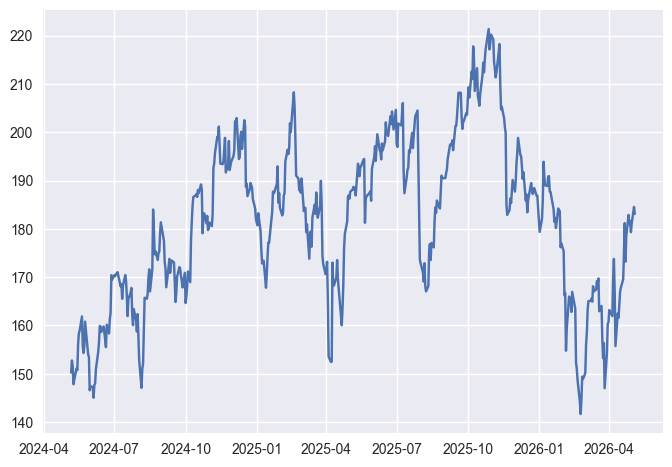

In [ ]:
# Plotting PANW stock after split
plt.plot(raw_df["Close"]["PANW"]) 

---
## 6. Sanity check — plot a few price series

**This is not optional.** Before saving anything, look at the data. Plot one stock from each sector. You're checking:
- Does the price history look continuous and plausible?
- Are there any obvious spikes or drops that look like data errors?
- Do the magnitudes make sense? (A $5 stock shouldn't suddenly show $500)

> **If something looks wrong here, fix it now** — every downstream notebook depends on this data being clean.

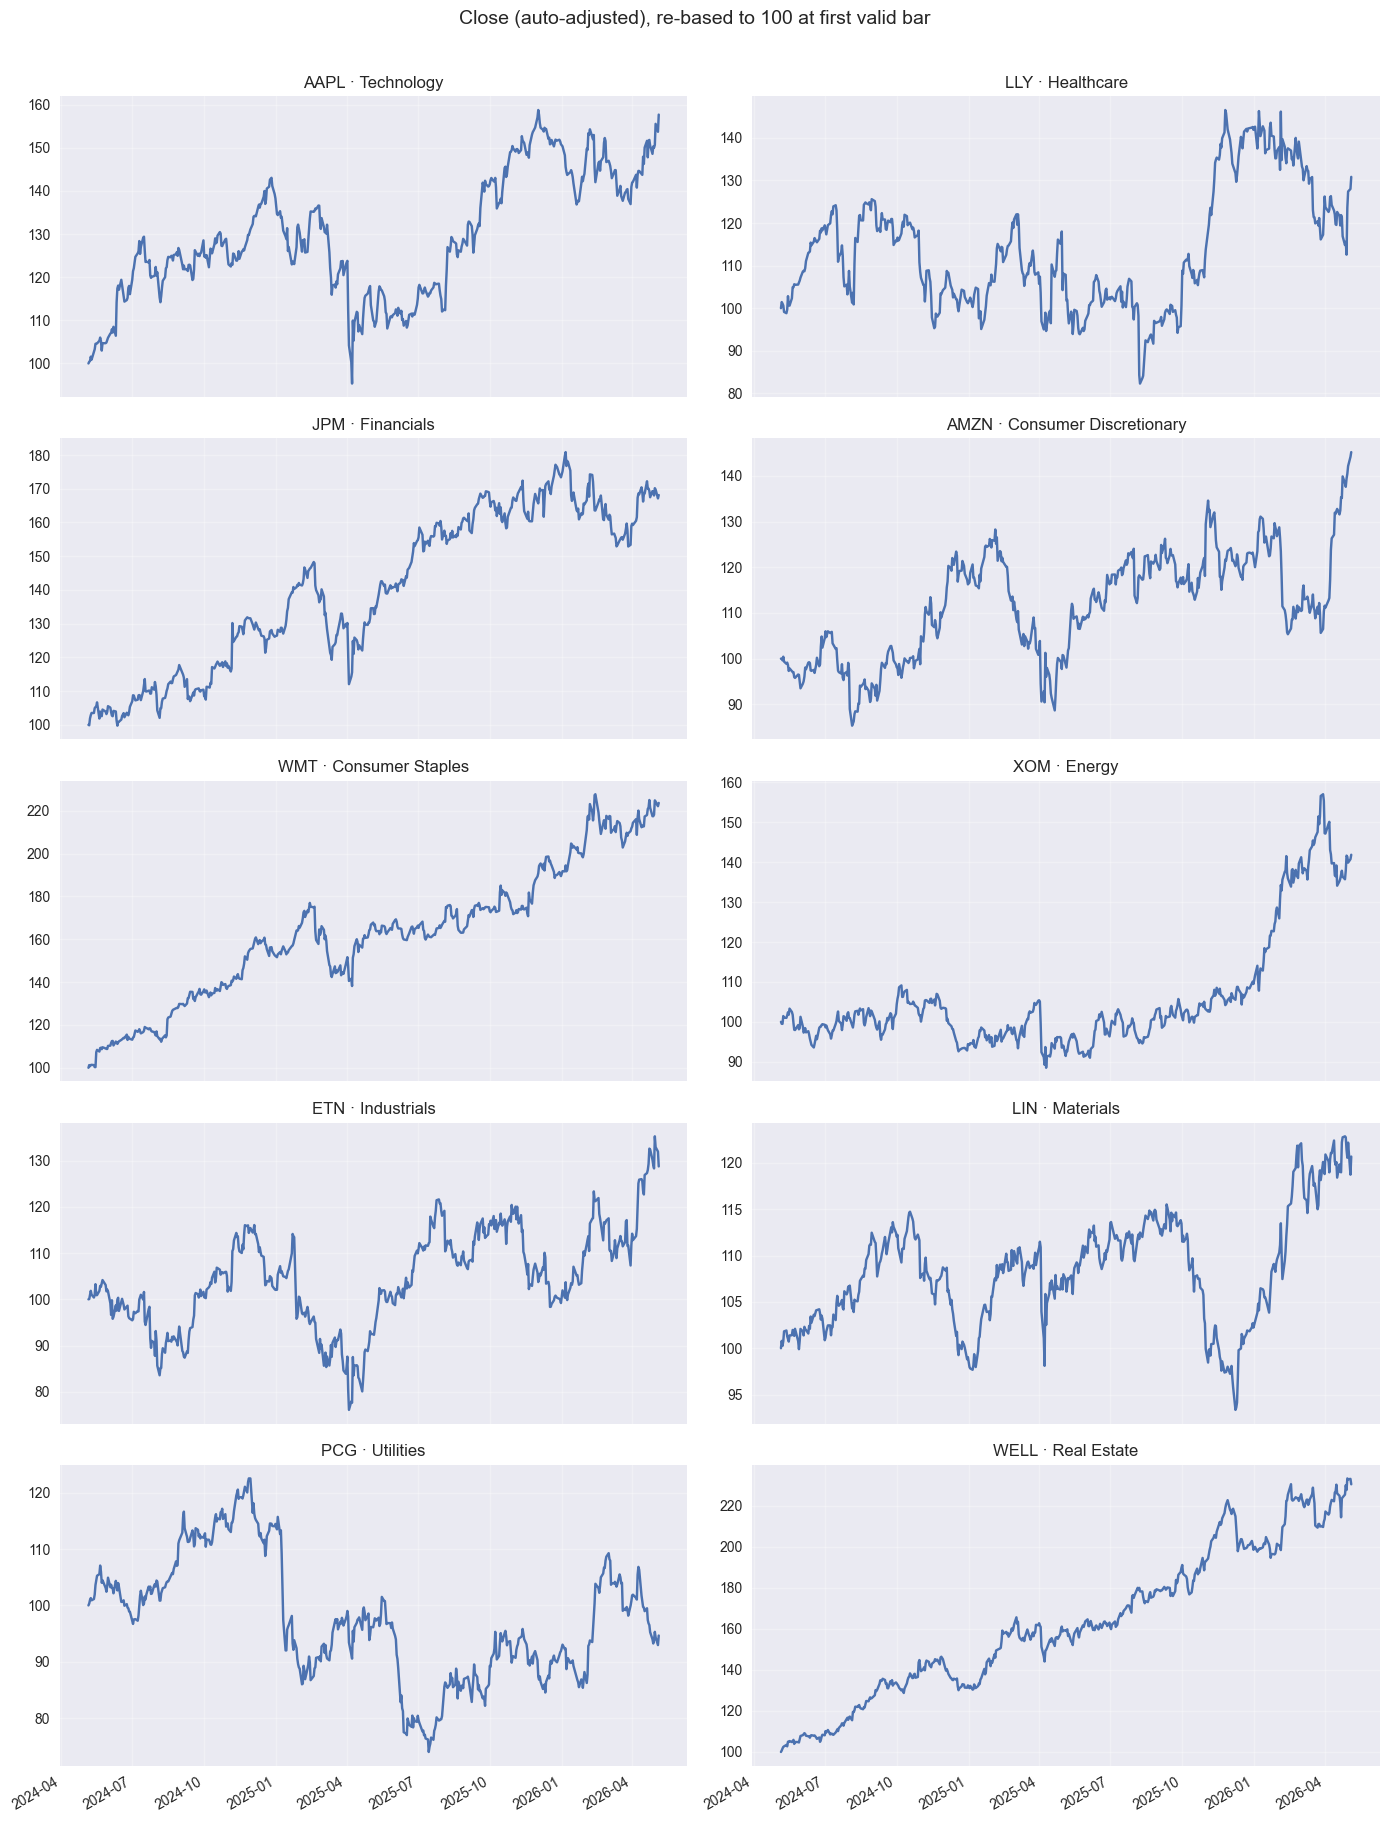

In [206]:
# TODO: pick one representative ticker per sector (10 tickers total)
REP_TICKERS = ["AAPL", "LLY", "JPM", "AMZN", "WMT", "XOM", "ETN", "LIN", "PCG", "WELL"]

TICKER_TO_SECTOR = {t: sector for sector, tickers in SECTORS.items() for t in tickers}

close = raw_df["Close"]
fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
axes = axes.ravel()

for ax, stock in zip(axes, REP_TICKERS):
    s = close[stock]
    norm = s / s.iloc[0] * 100
    ax.plot(norm.index, norm.values)
    sector = TICKER_TO_SECTOR[stock]
    ax.set_title(f"{stock} · {sector}")
    ax.grid(True, alpha=0.3)

fig.suptitle("Close (auto-adjusted), re-based to 100 at first valid bar", fontsize=14, y=1.01)
fig.autofmt_xdate()
plt.tight_layout()

# QUESTION TO ANSWER: Any surprises? Any that look flat, spikey, or truncated?

---
## 7. Persist to parquet

**Why parquet over CSV:**
- Preserves dtypes (DatetimeIndex stays a DatetimeIndex, no re-parsing)
- Significantly faster read for large DataFrames
- Smaller file size due to columnar compression

**What to save:** The cleaned `prices` DataFrame, plus a sector mapping so downstream notebooks know which ticker belongs to which sector.

In [209]:
# TODO: save prices to DATA_DIR / 'prices.parquet'
DATA_DIR.mkdir(parents=True, exist_ok=True)

prices_path = DATA_DIR / "prices.parquet"
sector_path = DATA_DIR / "sector_map.parquet"

raw_df.to_parquet(prices_path)

# TODO: save a sector_map (ticker -> sector) as a parquet or JSON
TICKER_TO_SECTOR = {t: sector for sector, tickers in SECTORS.items() for t in tickers}
sector_df = pd.Series(TICKER_TO_SECTOR, name="sector").rename_axis("ticker").reset_index()
sector_df.to_parquet(sector_path, index=False)

# TODO: print file sizes for both — compare to what a CSV equivalent would be


def _kib(path: Path) -> float:
    return path.stat().st_size / 1024


print(raw_df.shape, f"| prices.parquet {_kib(prices_path):.1f} KiB")
print(sector_df.shape, f"| sector_map.parquet {_kib(sector_path):.1f} KiB")

csv_path = DATA_DIR / "_prices_size_probe.csv"
raw_df.to_csv(csv_path)
print(f"CSV sanity (same raw_df written then removed): {_kib(csv_path):.1f} KiB")
csv_path.unlink()

# TODO: reload from parquet and verify shape + dtypes match what you saved
raw_df_chk = pd.read_parquet(prices_path)
sector_chk = pd.read_parquet(sector_path)
assert raw_df_chk.shape == raw_df.shape
print("Reload OK shapes:", raw_df_chk.shape, sector_chk.shape)



OSError: Cannot save file into a non-existent directory: 'backend/data'

---
## 8. Summary & handoff notes

Before closing this notebook, fill in these answers. Notebook 2 (feature engineering) will depend on them.

```
Final universe size:         ___ tickers  (started with ~150)
Tickers dropped:             ___ (list them + reason)
Date range:                  ___ to ___
Trading days in dataset:     ___
Missing data after cleaning: ___ nulls remaining
Price column used:           Adj Close
Parquet output:              data/prices.parquet, data/sector_map.parquet
```

**Known issues / things to watch in Notebook 2:**
- [ ] Any sectors that lost multiple tickers? (May skew sector analysis)
- [ ] Any tickers with suspicious price series that passed the threshold but look odd?
- [ ] Rolling windows in feature engineering need at least 52 weeks of data — flag any borderline tickers